# 02 - Daily Trader Training

Train the position-aware GRU controller on the daily FinCast cache. FinCast stays frozen; this notebook only reads cached FinCast distribution patches and learns the trader head that maps forecast distributions to next-day positions.

The default setting uses a daily label (`holding_horizon=1`) and only feeds the first `input_horizon=5` forecast steps into the trader. Change `input_horizon` to run the horizon ablation without rebuilding the cache.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

WORKSPACE_ROOT = Path.cwd().resolve()
if WORKSPACE_ROOT.name == 'notebooks':
    WORKSPACE_ROOT = WORKSPACE_ROOT.parent
if str(WORKSPACE_ROOT) not in sys.path:
    sys.path.insert(0, str(WORKSPACE_ROOT))

from src.datasets.trader_dataset import CachedDistributionDataset, time_ordered_train_test_indices
from src.fincast_io.cache_builder import load_distribution_cache
from src.fincast_io.forecast_features import forecast_to_return_patch
from src.trader.cnn_gru import PositionAwareGRUPolicy
from src.trader.encoder_transformer import EncoderTransformerPolicyConfig, EncoderTransformerPolicy
from src.training.losses import MeanVarianceTurnoverLoss
from src.training.trainer import evaluate_policy, train_one_epoch
from src.utils.config import PositionControllerConfig, PositionLossConfig

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'workspace: {WORKSPACE_ROOT}')
print(f'device:    {device}')


workspace: E:\Working Area\Comp5329_Assignment2_2026
device:    cuda


## 1. Config

All training controls are inline. `model_kind` selects the trader head on top of frozen FinCast outputs:

- `encoder_transformer`: FinCast forecast patch -> vanilla TransformerEncoder -> GRU -> position head.
- `cnn_gru`: FinCast forecast patch -> Conv1D encoder -> GRU -> position head.

For horizon ablation, edit only `input_horizon`; the cache keeps the full 32-step FinCast distribution, and the notebook slices the first K steps before training.


In [2]:
cache_path = WORKSPACE_ROOT / 'data/cache/position_fincast_daily_cache.npz'
model_kind = 'encoder_transformer'  # 'encoder_transformer' or 'cnn_gru'
checkpoint_path = WORKSPACE_ROOT / 'outputs/checkpoints' / f'trader_daily_{model_kind}_h5.pt'

seed = 42
input_horizon = 5 # Try 1, 3, 5, 10, 16, or 32 without rebuilding cache.
seq_len = 32
dataset_stride = 32
test_fraction = 0.2
batch_size = 32
epochs = 50
learning_rate = 1e-3
weight_decay = 0.0
grad_clip = 1.0  # None disables clipping.
initial_position = 0.0

if model_kind == 'encoder_transformer':
    controller_cfg = EncoderTransformerPolicyConfig(horizon_len=input_horizon)
elif model_kind == 'cnn_gru':
    controller_cfg = PositionControllerConfig(horizon_len=input_horizon)
else:
    raise ValueError(f'Unsupported model_kind: {model_kind}')
loss_cfg = PositionLossConfig()

torch.manual_seed(seed)
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

print('cache:       ', cache_path)
print('model_kind:  ', model_kind)
print('checkpoint:  ', checkpoint_path)
print('controller:  ', controller_cfg)
print('loss:        ', loss_cfg)
print('train setup: ', {
    'seed': seed,
    'model_kind': model_kind,
    'input_horizon': input_horizon,
    'seq_len': seq_len,
    'dataset_stride': dataset_stride,
    'test_fraction': test_fraction,
    'batch_size': batch_size,
    'epochs': epochs,
    'lr': learning_rate,
    'grad_clip': grad_clip,
})


cache:        E:\Working Area\Comp5329_Assignment2_2026\data\cache\position_fincast_daily_cache.npz
model_kind:   encoder_transformer
checkpoint:   E:\Working Area\Comp5329_Assignment2_2026\outputs\checkpoints\trader_daily_encoder_transformer_h5.pt
controller:   EncoderTransformerPolicyConfig(horizon_len=5, forecast_channels=10, model_dim=64, state_dim=64, num_layers=2, num_heads=4, ff_dim=128, dropout=0.1, max_trade=0.25, min_position=0.0, max_position=1.0, round_step=0.01)
loss:         PositionLossConfig(lambda_variance=1.0, lambda_turnover=0.001, lambda_forecast_risk=0.0, eps=1e-08)
train setup:  {'seed': 42, 'model_kind': 'encoder_transformer', 'input_horizon': 5, 'seq_len': 32, 'dataset_stride': 32, 'test_fraction': 0.2, 'batch_size': 32, 'epochs': 50, 'lr': 0.001, 'grad_clip': 1.0}


## 2. Load Daily FinCast Cache

The daily cache has one sample per asset per decision date. `full_outputs` is the frozen FinCast price-level distribution with shape `[N, 32, 10]`. `realized_returns` is the next trading day's realized return because the cache was generated with `holding_horizon=1`.


In [3]:
raw_cache = np.load(cache_path, allow_pickle=True)
cache = load_distribution_cache(cache_path)
level_patches = torch.as_tensor(cache['full_outputs'], dtype=torch.float32)
last_values = torch.as_tensor(cache['last_values'], dtype=torch.float32)
realized_returns = torch.as_tensor(cache['realized_returns'], dtype=torch.float32)
asset_names = cache['asset_names']
dates = cache['dates']

meta_keys = ['context_len', 'horizon_len', 'holding_horizon', 'data_frequency']
cache_meta = {key: raw_cache[key].item() for key in meta_keys if key in raw_cache}
asset_counts = dict(zip(*np.unique(asset_names, return_counts=True))) if asset_names.size else {}

print(f'cache path:      {cache_path}')
print(f'cache meta:      {cache_meta}')
print(f'level_patches:   {tuple(level_patches.shape)}')
print(f'last_values:     {tuple(last_values.shape)}')
print(f'realized_ret:    {tuple(realized_returns.shape)}')
print(f'asset counts:    {asset_counts}')
print(f'date range:      {dates[0]} .. {dates[-1]}')


cache path:      E:\Working Area\Comp5329_Assignment2_2026\data\cache\position_fincast_daily_cache.npz
cache meta:      {'context_len': 128, 'horizon_len': 32, 'holding_horizon': 1, 'data_frequency': 'D'}
level_patches:   (37608, 32, 10)
last_values:     (37608,)
realized_ret:    (37608,)
asset counts:    {'EEM': np.int64(4701), 'GLD': np.int64(4701), 'IWM': np.int64(4701), 'QQQ': np.int64(4701), 'SPY': np.int64(4701), 'TLT': np.int64(4701), 'USO': np.int64(4701), 'UUP': np.int64(4701)}
date range:      2007-08-30 .. 2026-05-07


## 3. Convert Forecast Levels To Return Patches

FinCast predicts price levels. The trader should see relative returns, so each forecast path is divided by the last observed price in that window. `input_horizon` then slices the near-horizon prefix used by the trader.


In [4]:
if not 1 <= input_horizon <= level_patches.shape[1]:
    raise ValueError(f'input_horizon must be in [1, {level_patches.shape[1]}].')

return_patches_full = forecast_to_return_patch(level_patches, last_values)
return_patches = return_patches_full[:, :input_horizon, :]

print(f'full return patches: {tuple(return_patches_full.shape)}')
print(f'trader input patch:  {tuple(return_patches.shape)}')
print(f'label mean/std:      {realized_returns.mean():.6f} / {realized_returns.std(unbiased=False):.6f}')


full return patches: (37608, 32, 10)
trader input patch:  (37608, 5, 10)
label mean/std:      0.000340 / 0.014672


## 4. Build Dataset And Time-Based Train/Test Split

`CachedDistributionDataset` turns daily samples into `seq_len`-step decision sequences. The split is time-based within each ETF: the first 80% of each asset's sequences train the model, and the most recent 20% test it.


In [5]:
dataset = CachedDistributionDataset(
    patches=return_patches,
    realized_returns=realized_returns,
    seq_len=seq_len,
    stride=dataset_stride,
    asset_names=asset_names if asset_names.size else None,
)

train_indices, test_indices = time_ordered_train_test_indices(
    dataset,
    test_fraction=test_fraction,
)
n_train = len(train_indices)
n_test = len(test_indices)
n_total = len(dataset)

train_set = Subset(dataset, train_indices)
test_set = Subset(dataset, test_indices)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

sample_batch = next(iter(train_loader))
print(f'sequences: train={n_train}  test={n_test}  total={n_total}  (time-based per asset)')
print(f'seq_len={seq_len}  dataset_stride={dataset_stride}  batch_size={batch_size}')
print({key: tuple(value.shape) for key, value in sample_batch.items()})


sequences: train=936  test=232  total=1168  (time-based per asset)
seq_len=32  dataset_stride=32  batch_size=32
{'patches': (32, 32, 5, 10), 'realized_returns': (32, 32)}


## 5. Build Model, Loss, And Optimizer

The default model is the encoder transformer head: it treats the near-horizon FinCast distribution as tokens, applies a standard TransformerEncoder, then feeds the pooled representation plus previous position into a GRU before predicting the bounded daily position. Set `model_kind='cnn_gru'` to compare against the Conv1D + GRU controller.


In [6]:
if model_kind == 'encoder_transformer':
    model = EncoderTransformerPolicy(controller_cfg).to(device)
elif model_kind == 'cnn_gru':
    model = PositionAwareGRUPolicy(controller_cfg).to(device)
else:
    raise ValueError(f'Unsupported model_kind: {model_kind}')

loss_fn = MeanVarianceTurnoverLoss(loss_cfg).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

n_params = sum(p.numel() for p in model.parameters())
print(f'model parameters: {n_params:,}')


E:\Working Area\Comp5329_Assignment2_2026\src\trader\encoder_transformer.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=config.num_layers)


model parameters: 109,825


## 6. Training Loop

The test set is used as a chronological holdout. The notebook keeps the best checkpoint state by test loss so later diagnostics inspect the best observed model rather than the last epoch.


In [7]:
history = {
    'train_loss': [],
    'test_loss': [],
    'test_meanret': [],
    'test_variance': [],
    'test_turnover': [],
}
log_every = max(1, epochs // 10)
best_test = float('inf')
best_state = None
best_epoch = 0

for epoch in range(1, epochs + 1):
    train_stats = train_one_epoch(
        model, loss_fn, train_loader, optimizer,
        device=device, initial_position=initial_position, grad_clip=grad_clip,
    )
    test_stats = evaluate_policy(
        model, loss_fn, test_loader,
        device=device, initial_position=initial_position,
    )

    history['train_loss'].append(train_stats['loss'])
    history['test_loss'].append(test_stats['loss'])
    history['test_meanret'].append(test_stats['mean_return'])
    history['test_variance'].append(test_stats['variance'])
    history['test_turnover'].append(test_stats['turnover'])

    if test_stats['loss'] < best_test:
        best_test = test_stats['loss']
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if epoch == 1 or epoch % log_every == 0 or epoch == epochs:
        print(
            f'epoch {epoch:03d}  '
            f'train={train_stats["loss"]:.6f}  '
            f'test={test_stats["loss"]:.6f}  '
            f'ret={test_stats["mean_return"]:.6f}  '
            f'var={test_stats["variance"]:.6f}  '
            f'turn={test_stats["turnover"]:.6f}'
        )

if best_state is not None:
    model.load_state_dict(best_state)
final_test_stats = evaluate_policy(
    model, loss_fn, test_loader,
    device=device, initial_position=initial_position,
)
print(f'best epoch: {best_epoch}')
print(f'best test_loss: {best_test:.6f}')
print('best test stats:', final_test_stats)


epoch 001  train=-0.000017  test=-0.000187  ret=0.000239  var=0.000036  turn=0.015625
epoch 005  train=-0.000055  test=-0.000190  ret=0.000244  var=0.000038  turn=0.015937
epoch 010  train=-0.000042  test=-0.000193  ret=0.000249  var=0.000039  turn=0.016250
epoch 015  train=-0.000070  test=-0.000182  ret=0.000230  var=0.000033  turn=0.015000
epoch 020  train=-0.000063  test=-0.000179  ret=0.000227  var=0.000033  turn=0.015312
epoch 025  train=-0.000054  test=-0.000179  ret=0.000225  var=0.000032  turn=0.014687
epoch 030  train=-0.000057  test=-0.000179  ret=0.000227  var=0.000032  turn=0.015312
epoch 035  train=-0.000043  test=-0.000179  ret=0.000225  var=0.000032  turn=0.014687
epoch 040  train=-0.000031  test=-0.000182  ret=0.000230  var=0.000033  turn=0.015000
epoch 045  train=-0.000046  test=-0.000187  ret=0.000239  var=0.000036  turn=0.015625
epoch 050  train=-0.000061  test=-0.000182  ret=0.000230  var=0.000033  turn=0.015000
best epoch: 41
best test_loss: -0.000216
best test sta

## 7. Loss Curves

Use these plots as a quick overfit check. Large train/test separation is a sign to reduce model capacity, increase turnover penalty, or shorten `input_horizon`.


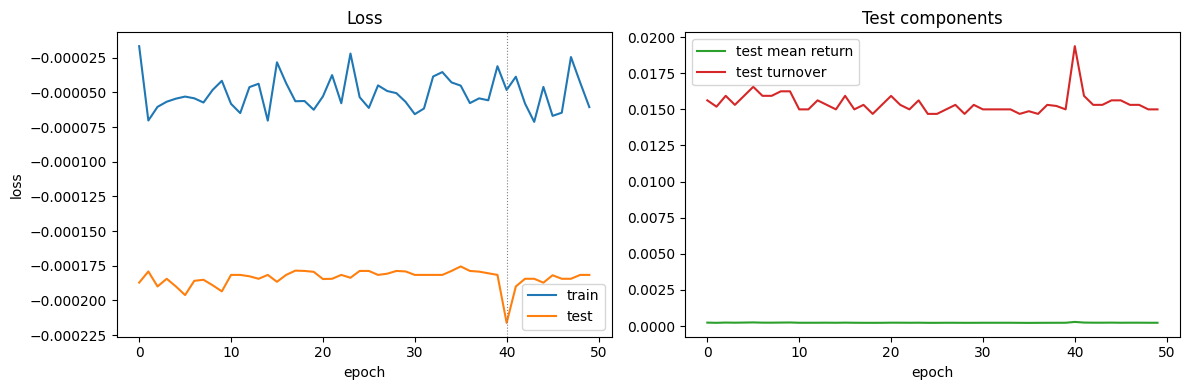

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['test_loss'], label='test')
axes[0].axvline(best_epoch - 1, color='gray', linestyle=':', linewidth=0.8)
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history['test_meanret'], label='test mean return', color='C2')
axes[1].plot(history['test_turnover'], label='test turnover', color='C3')
axes[1].set_xlabel('epoch')
axes[1].set_title('Test components')
axes[1].legend()

plt.tight_layout()
plt.show()


## 8. Inspect A Test Sequence

This cell shows the position path, trade increments, and realized P&L for one chronological test sequence.


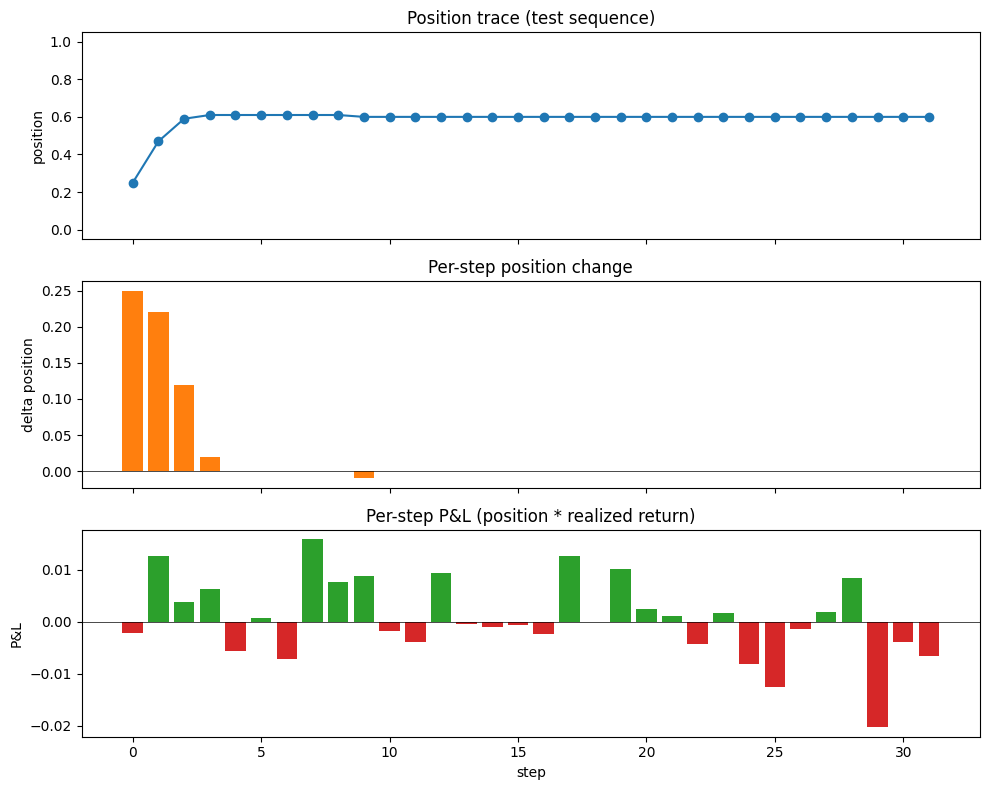

unique positions in trace: 5
sample values:             [0.25 0.47 0.59 0.6  0.61]
sequence return:           0.021283


In [9]:
model.eval()
sample_loader = DataLoader(test_set, batch_size=1, shuffle=False)
sample = next(iter(sample_loader))
sample = {k: v.to(device) for k, v in sample.items()}
with torch.no_grad():
    rollout = model(sample['patches'], initial_position=initial_position)

positions = rollout.positions[0].cpu().numpy()
deltas = rollout.deltas[0].cpu().numpy()
rets = sample['realized_returns'][0].cpu().numpy()
pnl = positions * rets

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(positions, marker='o', color='C0')
axes[0].set_ylabel('position')
axes[0].set_ylim(-0.05, 1.05)
axes[0].set_title('Position trace (test sequence)')

axes[1].bar(range(len(deltas)), deltas, color='C1')
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_ylabel('delta position')
axes[1].set_title('Per-step position change')

axes[2].bar(range(len(pnl)), pnl, color=['C2' if x >= 0 else 'C3' for x in pnl])
axes[2].axhline(0, color='k', linewidth=0.5)
axes[2].set_xlabel('step')
axes[2].set_ylabel('P&L')
axes[2].set_title('Per-step P&L (position * realized return)')

plt.tight_layout()
plt.show()

unique_positions = np.unique(np.round(positions, 4))
print(f'unique positions in trace: {len(unique_positions)}')
print(f'sample values:             {unique_positions[:10]}')
print(f'sequence return:           {pnl.sum():.6f}')


## 9. Position Distribution Across Test Sequences

This checks whether the learned policy actually uses the position range or collapses to one nearly constant exposure.


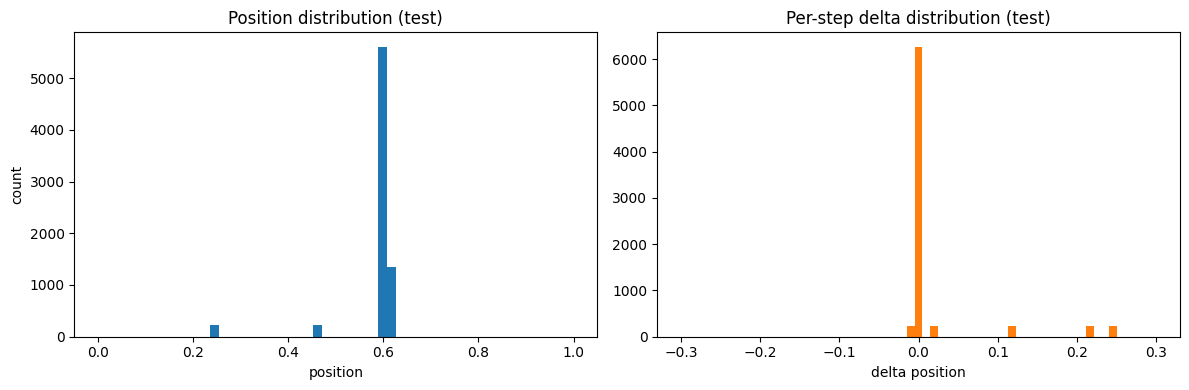

steps with no trade (|delta| < 1e-6): 6264 / 7424
unique positions across all test: 5


In [10]:
all_positions = []
all_deltas = []
model.eval()
with torch.no_grad():
    for batch in DataLoader(test_set, batch_size=batch_size, shuffle=False):
        batch = {k: v.to(device) for k, v in batch.items()}
        rollout = model(batch['patches'], initial_position=initial_position)
        all_positions.append(rollout.positions.cpu().numpy())
        all_deltas.append(rollout.deltas.cpu().numpy())
all_positions = np.concatenate(all_positions).ravel()
all_deltas = np.concatenate(all_deltas).ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(all_positions, bins=51, range=(0, 1), color='C0')
axes[0].set_xlabel('position')
axes[0].set_ylabel('count')
axes[0].set_title('Position distribution (test)')

axes[1].hist(all_deltas, bins=61, range=(-0.3, 0.3), color='C1')
axes[1].set_xlabel('delta position')
axes[1].set_title('Per-step delta distribution (test)')

plt.tight_layout()
plt.show()

n_no_trade = int((np.abs(all_deltas) < 1e-6).sum())
print(f'steps with no trade (|delta| < 1e-6): {n_no_trade} / {len(all_deltas)}')
print(f'unique positions across all test: {len(np.unique(np.round(all_positions, 4)))}')


## 10. Save Checkpoint

The checkpoint includes model weights, config, training history, cache path, and split metadata so the run can be reconstructed later.


In [11]:
torch.save({
    'epoch': best_epoch,
    'model': model.state_dict(),
    'best_state': best_state,
    'controller_config': controller_cfg.__dict__,
    'loss_config': loss_cfg.__dict__,
    'history': history,
    'best_test_loss': best_test,
    'best_test_stats': final_test_stats,
    'cache_path': str(cache_path),
    'model_kind': model_kind,
    'input_horizon': input_horizon,
    'seq_len': seq_len,
    'dataset_stride': dataset_stride,
    'test_fraction': test_fraction,
    'train_sequences': n_train,
    'test_sequences': n_test,
}, checkpoint_path)
print(f'saved -> {checkpoint_path}')


saved -> E:\Working Area\Comp5329_Assignment2_2026\outputs\checkpoints\trader_daily_encoder_transformer_h5.pt
